In [1]:
import zipfile

zip_path = "/content/ORIE5270-finalproject-ozone-aqi-prediction-main.zip"
extract_path = "/content"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

In [2]:
import pandas as pd
import os

path = "/content/ORIE5270-finalproject-ozone-aqi-prediction-main/data_processing/data/processed/modeling_table.csv"

df = pd.read_csv(path)

print(df.shape)
df.head()

(588, 28)


,location_label,grid_latitude,grid_longitude,weathercode,temperature_2m_mean,temperature_2m_max,temperature_2m_min,sunrise,sunset,daylight_duration,...,shortwave_radiation_sum,forecasting,date,State Name,county Name,AQI,Category,Defining Parameter,Defining Site,Number of Sites Reporting
0,tompkins_county_ny,42.448944,-76.498665,3,-0.3,1.3,-1.3,2024-01-01 08:35:00,2024-01-01 17:43:00,32872.94,...,4.62,open_meteo_historical_forecasting,2024-01-01,New York,Tompkins,25.0,Good,Ozone,36-109-9991,1.0
1,tompkins_county_ny,42.448944,-76.498665,3,0.9,4.4,-1.0,2024-01-02 08:35:00,2024-01-02 17:44:00,32921.10,...,3.97,open_meteo_historical_forecasting,2024-01-02,New York,Tompkins,28.0,Good,Ozone,36-109-9991,1.0
2,tompkins_county_ny,42.448944,-76.498665,3,1.7,3.4,0.5,2024-01-03 08:35:00,2024-01-03 17:45:00,32973.20,...,2.99,open_meteo_historical_forecasting,2024-01-03,New York,Tompkins,22.0,Good,Ozone,36-109-9991,1.0
3,tompkins_county_ny,42.448944,-76.498665,73,-0.9,1.3,-5.3,2024-01-04 08:35:00,2024-01-04 17:46:00,33029.15,...,6.49,open_meteo_historical_forecasting,2024-01-04,New York,Tompkins,32.0,Good,Ozone,36-109-9991,1.0
4,tompkins_county_ny,42.448944,-76.498665,3,-3.2,0.7,-6.1,2024-01-05 08:35:00,2024-01-05 17:47:00,33088.85,...,7.74,open_meteo_historical_forecasting,2024-01-05,New York,Tompkins,32.0,Good,Ozone,36-109-9991,1.0


In [3]:
df.columns

Index(['location_label', 'grid_latitude', 'grid_longitude', 'weathercode',
       'temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min',
       'sunrise', 'sunset', 'daylight_duration', 'sunshine_duration',
       'precipitation_sum', 'rain_sum', 'snowfall_sum', 'precipitation_hours',
       'windspeed_10m_max', 'windgusts_10m_max', 'winddirection_10m_dominant',
       'shortwave_radiation_sum', 'forecasting', 'date', 'State Name',
       'county Name', 'AQI', 'Category', 'Defining Parameter', 'Defining Site',
       'Number of Sites Reporting'],
      dtype='object')

In [5]:
target = "AQI"

numeric_df = df.select_dtypes(include=["number"])

X = numeric_df.drop(columns=[target])
y = numeric_df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)
print(X.columns)

X shape: (588, 17)
y shape: (588,)
Index(['grid_latitude', 'grid_longitude', 'weathercode', 'temperature_2m_mean',
       'temperature_2m_max', 'temperature_2m_min', 'daylight_duration',
       'sunshine_duration', 'precipitation_sum', 'rain_sum', 'snowfall_sum',
       'precipitation_hours', 'windspeed_10m_max', 'windgusts_10m_max',
       'winddirection_10m_dominant', 'shortwave_radiation_sum',
       'Number of Sites Reporting'],
      dtype='object')


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (470, 17)
Test set: (118, 17)


In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MSE:", rf_mse)
print("MAE:", rf_mae)
print("R2:", rf_r2)

Random Forest Results
MSE: 27.37253156779661
MAE: 4.172754237288135
R2: 0.5621994725857141


In [8]:
!pip install xgboost
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

xgb_mse = mean_squared_error(y_test, y_pred_xgb)
xgb_mae = mean_absolute_error(y_test, y_pred_xgb)
xgb_r2 = r2_score(y_test, y_pred_xgb)

print("XGBoost Results")
print("MSE:", xgb_mse)
print("MAE:", xgb_mae)
print("R2:", xgb_r2)

XGBoost Results
MSE: 27.05828234249871
MAE: 4.316274788420079
R2: 0.5672256235734002


In [9]:
results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "MSE": [rf_mse, xgb_mse],
    "MAE": [rf_mae, xgb_mae],
    "R2": [rf_r2, xgb_r2]
})

results

,Model,MSE,MAE,R2
0,Random Forest,27.372532,4.172754,0.562199
1,XGBoost,27.058282,4.316275,0.567226


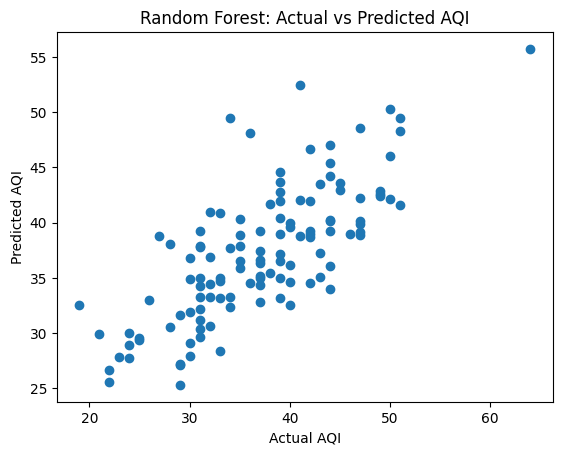

In [10]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Random Forest: Actual vs Predicted AQI")
plt.show()

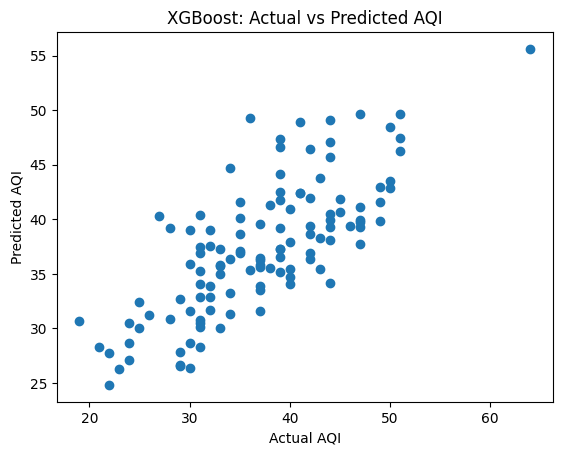

In [11]:
plt.scatter(y_test, y_pred_xgb)
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("XGBoost: Actual vs Predicted AQI")
plt.show()

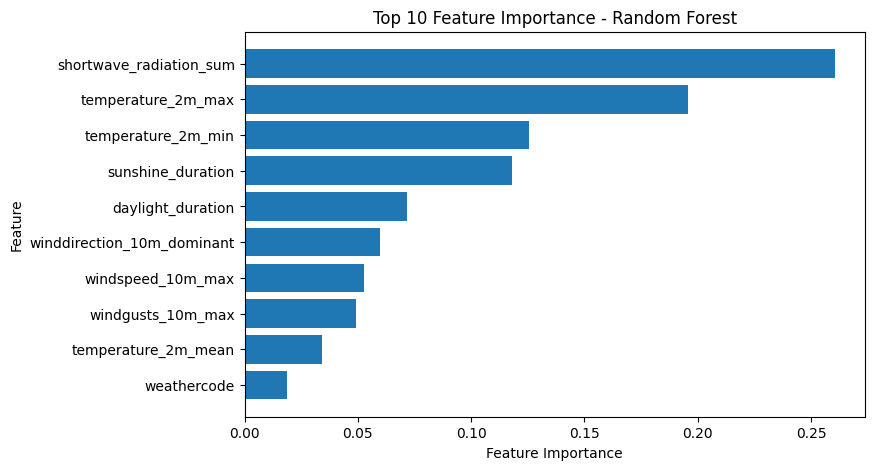

,Feature,Importance
15,shortwave_radiation_sum,0.260632
4,temperature_2m_max,0.195603
5,temperature_2m_min,0.125371
7,sunshine_duration,0.117790
6,daylight_duration,0.071791
14,winddirection_10m_dominant,0.059541
12,windspeed_10m_max,0.052737
13,windgusts_10m_max,0.049341
3,temperature_2m_mean,0.034267
2,weathercode,0.018637


In [12]:
import pandas as pd
import matplotlib.pyplot as plt

rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

rf_importance = rf_importance.sort_values(by="Importance", ascending=False).head(10)

plt.figure(figsize=(8, 5))
plt.barh(rf_importance["Feature"], rf_importance["Importance"])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance - Random Forest")
plt.gca().invert_yaxis()
plt.show()

rf_importance

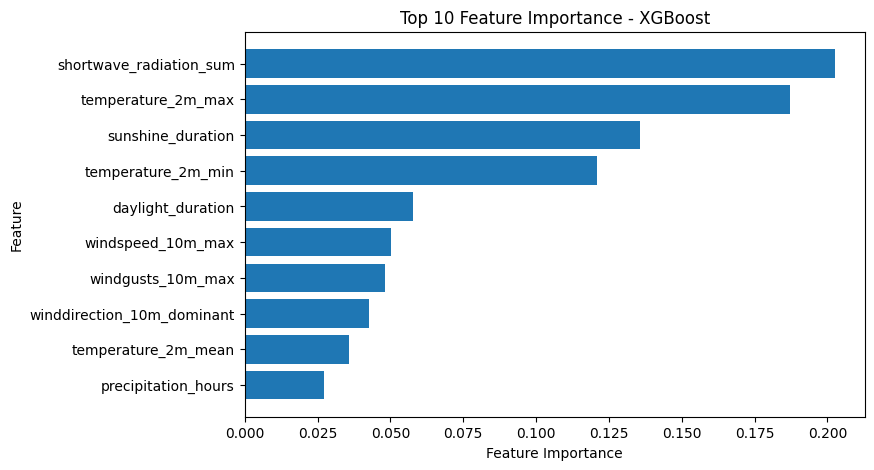

,Feature,Importance
15,shortwave_radiation_sum,0.202623
4,temperature_2m_max,0.187052
7,sunshine_duration,0.135730
5,temperature_2m_min,0.120949
6,daylight_duration,0.057599
12,windspeed_10m_max,0.050214
13,windgusts_10m_max,0.048182
14,winddirection_10m_dominant,0.042745
3,temperature_2m_mean,0.035911
11,precipitation_hours,0.027283


In [13]:
xgb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

xgb_importance = xgb_importance.sort_values(by="Importance", ascending=False).head(10)

plt.figure(figsize=(8, 5))
plt.barh(xgb_importance["Feature"], xgb_importance["Importance"])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance - XGBoost")
plt.gca().invert_yaxis()
plt.show()

xgb_importance